In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 5
n_var = 100
n_components = 7
n_datapoints = 50000
locs_range = 2
batch_size = 32

In [19]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 25 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device)), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]

                if data is not None:
                    softmax_shift = pyro.param('softmax_shift', out_mu.detach().exp().sum(-1).mean().log())
                    logits = out_mu - total_counts.log() + l.log() - softmax_shift
                    recon = pyro.sample('obs', dist.NegativeBinomial(total_count=total_counts, logits=logits,validate_args=False).to_event(1), obs=data)
                    b_dist = dist.Bernoulli(probs=(torch.sigmoid(logits)+torch.finfo(torch.float32).tiny)**total_counts).to_event(1)#p(0)=(1-p)**r
                    b_out=pyro.sample("b",b_dist, obs=(data>0.).float())
                    return recon

    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent)), infer={"enumerate": "parallel"})


In [20]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 12*torch.rand(n_var)-6.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [21]:
(data>0).sum(0)

tensor([ 2152, 16572, 15776,   966,   128, 18456,  3078, 37622, 23598,    26,
        11655, 11509,  4545,   694,  6533, 15787,    13,  8219, 48103,  3208,
        13654,  5268,   613, 31525, 10803, 25976, 15078,   232,  6052,  5170,
         1337, 29246, 26745,    18, 18474, 22700,    53,    51, 21840,   110,
        29068,  2670,     2,   139, 32256,  7877,  7019, 34988, 10944, 26872,
           32, 20199, 32153, 15123,  8278, 22312,    82,  3310, 19540, 43719,
        17335, 33882,  2681, 11926, 16348, 21822,  1543, 10798, 16022,   447,
         1128,    95, 19093,    82, 32138, 27442,  9645, 16204,   623, 16798,
        36267, 27881,  6591,   185,  9122,  1250,  4001, 29632, 24086, 24989,
          362, 25375,  4185, 31005,  1580, 17267,   522,  5710,  8099, 15149])

<Axes: ylabel='Count'>

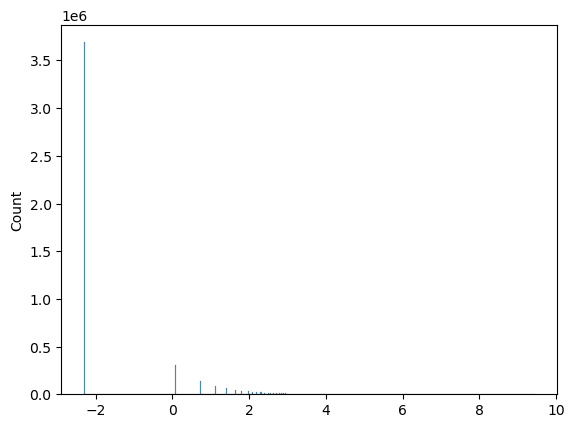

In [22]:
seaborn.histplot(np.log(data.flatten()+0.1))

<Axes: ylabel='Count'>

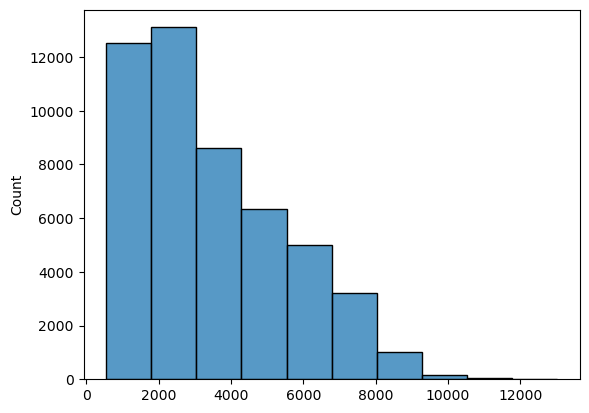

In [23]:
seaborn.histplot(data.sum(1).flatten(),bins=10)

In [24]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [25]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)

# SVI setup
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
svi = SVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 15
losses = []

In [26]:
for i in tqdm.tqdm(range(num_iterations)):
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  7%|▋         | 1/15 [00:41<09:37, 41.28s/it]

Iteration 0 : Loss 0.4180542230606079


 13%|█▎        | 2/15 [01:15<08:00, 36.99s/it]

Iteration 1 : Loss 0.35519835352897644


 20%|██        | 3/15 [01:48<07:04, 35.39s/it]

...

Iteration 12 : Loss 0.6376950740814209


 93%|█████████▎| 14/15 [07:45<00:31, 31.87s/it]

Iteration 13 : Loss 0.38501036167144775


100%|██████████| 15/15 [08:16<00:00, 33.13s/it]

Iteration 14 : Loss 0.359258234500885
Training complete.


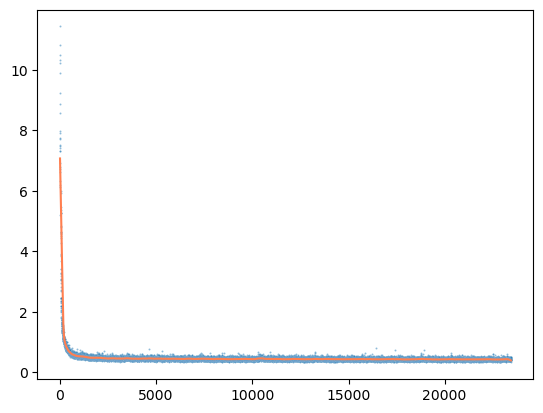

In [27]:
antipode.plotting.plot_loss(losses)

In [28]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [29]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [30]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


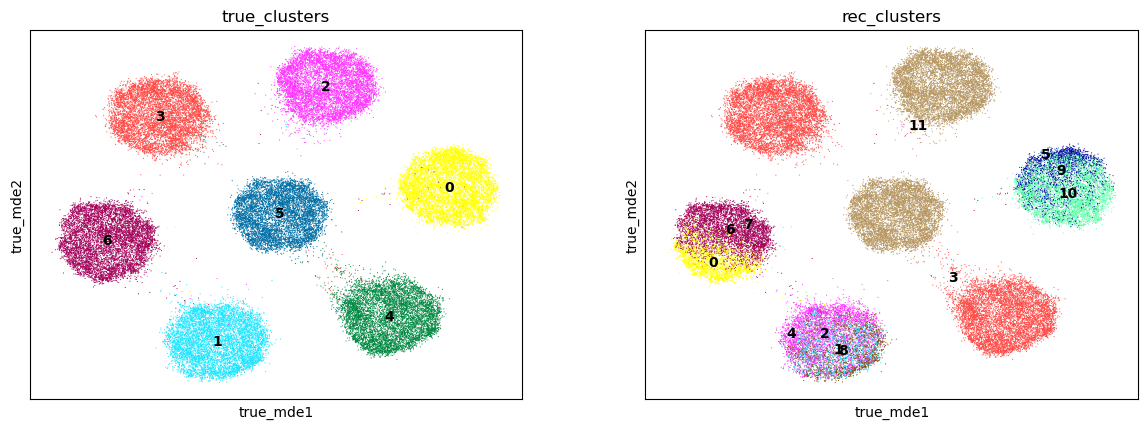

In [31]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


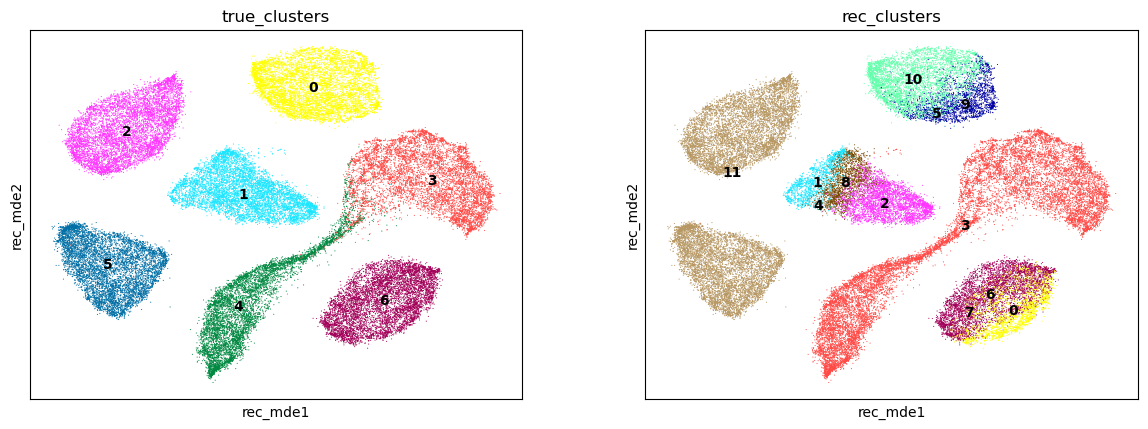

In [32]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [33]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

100%|██████████| 12/12 [00:00<00:00, 255.73it/s]


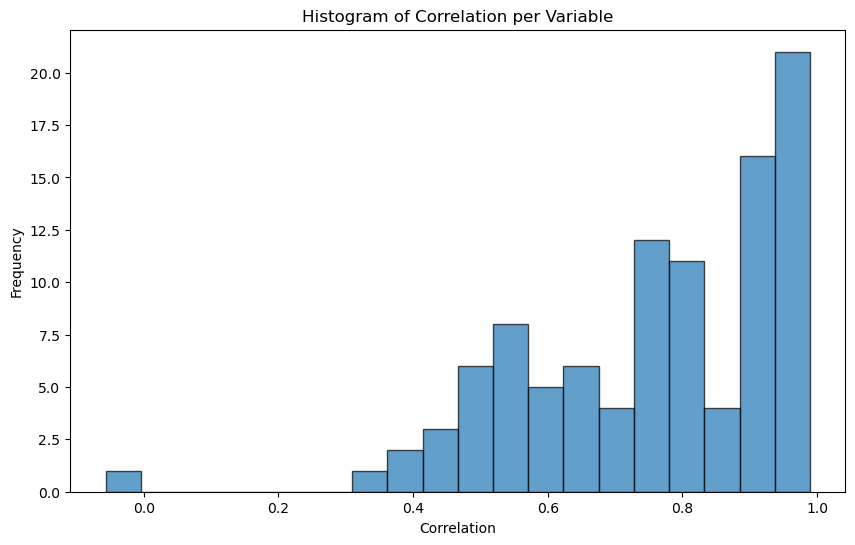

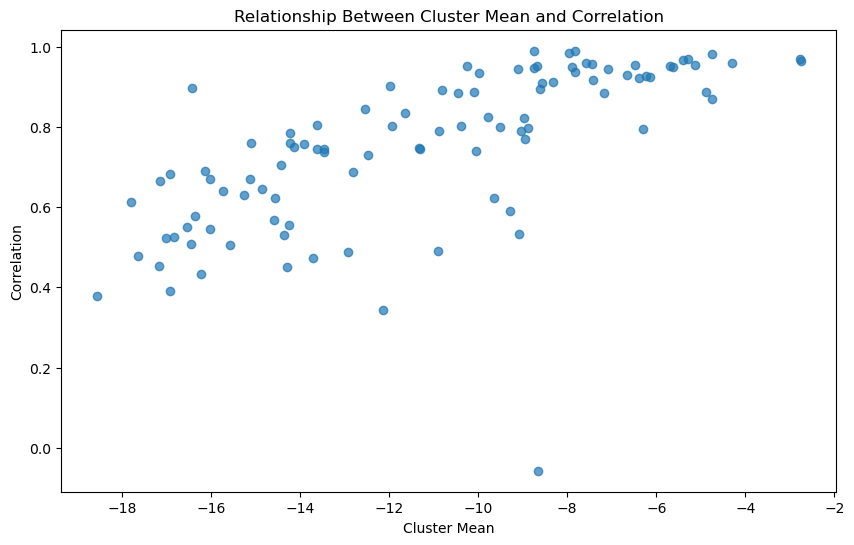

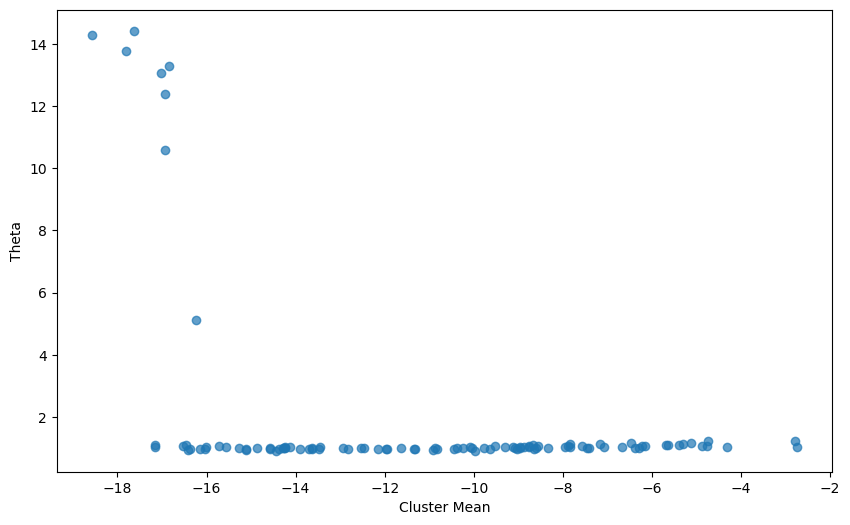

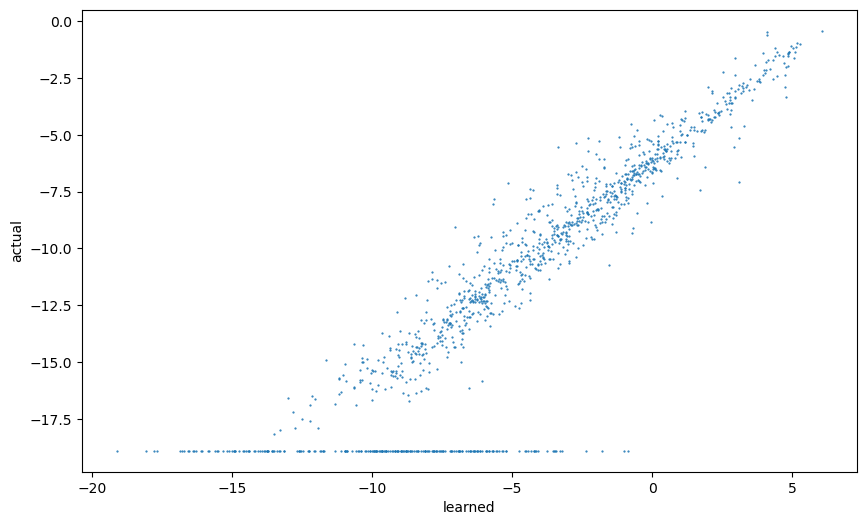

In [34]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()
